# PRELIMINARY NOTEBOOK (Data Cleaning + EDA)

## Purpose:
###   1) Clean and standardize the master panel dataset
###   2) Engineer regime dummies + policy variables
###   3) Harmonize political classification across non-election years
###   4) Build core interaction-ready features
###   5) Run pre-model diagnostics + exploratory analysis

# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor

from pathlib import Path
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# Load data

In [2]:
DATA_PATH = Path("MasterPanel.csv")
df = pd.read_csv(DATA_PATH)

print("Shape (raw):", df.shape)
display(df.head())
display(df.tail())

Shape (raw): (5760, 11)


,state,year,month,unemployment_rate,UPT,PostCOVID,VRM,StringencyIndex,GDP_billions,red,blue
0,Alabama,2016,1,6.3,427880.0,0,469390.0,NaN,211.14,1.0,0.0
1,Alabama,2016,2,6.2,442620.0,0,478792.0,NaN,211.14,1.0,0.0
2,Alabama,2016,3,5.9,457598.0,0,518498.0,NaN,211.14,1.0,0.0
3,Alabama,2016,4,5.4,452035.0,0,493900.0,NaN,212.80,1.0,0.0
4,Alabama,2016,5,5.3,435872.0,0,490068.0,NaN,212.80,1.0,0.0


,state,year,month,unemployment_rate,UPT,PostCOVID,VRM,StringencyIndex,GDP_billions,red,blue
5755,Wisconsin,2025,8,3.2,2815160.0,1,2211406.0,NaN,NaN,NaN,NaN
5756,Wisconsin,2025,9,2.7,3313578.0,1,2148856.0,NaN,NaN,NaN,NaN
5757,Wisconsin,2025,10,2.7,3392218.0,1,2257323.0,NaN,NaN,NaN,NaN
5758,Wisconsin,2025,11,2.7,2782692.0,1,2073789.0,NaN,NaN,NaN,NaN
5759,Wisconsin,2025,12,3.0,2532809.0,1,2172246.0,NaN,NaN,NaN,NaN


# Standardize schema and basic types

In [3]:
# Expected columns (based on your merged master panel)
expected_cols = {
    "state", "year", "month",
    "unemployment_rate", "UPT", "VRM",
    "StringencyIndex", "GDP_billions",
    "red", "blue"
}

missing_expected = expected_cols.difference(df.columns)
if missing_expected:
    print("WARNING: Missing expected columns:", missing_expected)

# Enforce types
df["state"] = df["state"].astype(str).str.strip()
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["month"] = pd.to_numeric(df["month"], errors="coerce").astype("Int64")

# Continuous vars
for col in ["unemployment_rate", "UPT", "VRM", "StringencyIndex", "GDP_billions"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Political dummies might arrive as 0/1 floats
for col in ["red", "blue"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Core integrity checks (panel sanity)

In [4]:
# 3.1 Check month range
invalid_months = df.loc[~df["month"].between(1, 12), ["state", "year", "month"]]
if len(invalid_months) > 0:
    print("WARNING: Found invalid months:")
    display(invalid_months.head(20))
else:
    print("OK: All months are within 1–12.")

# 3.2 Check duplicate keys
key_cols = ["state", "year", "month"]
dup_mask = df.duplicated(subset=key_cols, keep=False)
dups = df.loc[dup_mask, key_cols].sort_values(key_cols)

if len(dups) > 0:
    print(f"WARNING: Found {len(dups)} duplicate state-year-month keys.")
    display(dups.head(30))
else:
    print("OK: No duplicate state-year-month keys.")

# 3.3 Basic non-negativity checks (flag only; do not drop yet)
nonneg_cols = ["UPT", "VRM", "GDP_billions", "StringencyIndex"]
for col in nonneg_cols:
    if col in df.columns:
        bad = df.loc[df[col].notna() & (df[col] < 0), ["state", "year", "month", col]]
        if len(bad) > 0:
            print(f"WARNING: {col} has negative values.")
            display(bad.head(20))

OK: All months are within 1–12.
OK: No duplicate state-year-month keys.


# Trim to analysis window (2016–2024)

In [5]:
# We decided the report will focus on 2016–2024
df = df.loc[(df["year"] >= 2016) & (df["year"] <= 2024)].copy()

print("Shape (2016–2024):", df.shape)

Shape (2016–2024): (5184, 11)


# Create a proper date index

In [6]:
df["date"] = pd.to_datetime(
    df["year"].astype(str) + "-" + df["month"].astype(str).str.zfill(2) + "-01",
    errors="coerce"
)

# Define COVID regime dummies
Regimes:  
Pre-COVID:        2016-01 to 2019-12  
COVID Emergency:  2020-04 to 2023-06  (inclusive)  
Post-Emergency:   2023-07 to 2024-12  (inclusive)  

In [7]:
emergency_start = pd.Timestamp("2020-04-01")
emergency_end   = pd.Timestamp("2023-06-01")
post_start      = pd.Timestamp("2023-07-01")

df["COVID_Emergency"] = ((df["date"] >= emergency_start) & (df["date"] <= emergency_end)).astype(int)
df["Post_Emergency"]  = (df["date"] >= post_start).astype(int)

# Sanity check (should never be 1 at the same time)
overlap = df.loc[(df["COVID_Emergency"] == 1) & (df["Post_Emergency"] == 1), key_cols + ["date"]]
if len(overlap) > 0:
    print("WARNING: Overlap between COVID_Emergency and Post_Emergency dummies!")
    display(overlap.head())
else:
    print("OK: No overlap between regime dummies.")

# Create a single regime label for EDA plots
def regime_label(row):
    if row["Post_Emergency"] == 1:
        return "Post-Emergency (Jul 2023–2024)"
    if row["COVID_Emergency"] == 1:
        return "COVID Emergency (Apr 2020–Jun 2023)"
    return "Pre-COVID (2016–2019)"

df["regime"] = df.apply(regime_label, axis=1)

OK: No overlap between regime dummies.


# Policy availability period for Stringency (2020–2022)

In [8]:
# Stringency is only available in 2020–2022
# separate policy window and build an "effective" stringency variable.
df["COVID_PolicyPeriod"] = df["year"].between(2020, 2022).astype(int)

# Effective Stringency: no NaNs outside policy window
df["Stringency_effective"] = df["StringencyIndex"].fillna(0) * df["COVID_PolicyPeriod"]

# Political variable harmonization (red/blue to single variable)
### Problem:  
   red/blue exists only for election years (2016, 2020, 2024) and is missing in between.  
### Goal:  
   create a single political indicator and "stretch" values across months between elections:  
     - 2016 value applies to 2017–2019  
     - 2020 value applies to 2021–2023  
     - 2024 applies to 2024  
We'll create "is_red" as the single indicator.

In [9]:
#initial is_red from 'red' if present; fall back to (1 - blue) if needed.
df["is_red_raw"] = np.where(df["red"].notna(), df["red"], np.where(df["blue"].notna(), 1 - df["blue"], np.nan))

# We'll build a year-level mapping by state, then expand it.
# 1) Extract election-year values per state
election_years = [2016, 2020, 2024]
pol_elec = (
    df.loc[df["year"].isin(election_years), ["state", "year", "is_red_raw"]]
      .dropna(subset=["is_red_raw"])
      .drop_duplicates(subset=["state", "year"])
      .sort_values(["state", "year"])
)

# 2) Create a state-year grid for 2016–2024
states = sorted(df["state"].unique())
years = list(range(2016, 2025))
state_year = pd.MultiIndex.from_product([states, years], names=["state", "year"]).to_frame(index=False)

# 3) Merge election values and forward-fill within each state
state_year = state_year.merge(pol_elec, on=["state", "year"], how="left")
state_year["is_red"] = state_year.groupby("state")["is_red_raw"].ffill()

# If any states still have NaN (no election info), keep NaN and we'll flag them
missing_pol_states = state_year.loc[state_year["is_red"].isna(), "state"].unique()
if len(missing_pol_states) > 0:
    print("WARNING: These states have no political classification after ffill:")
    print(missing_pol_states)

# 4) Merge is_red back to monthly df
df = df.merge(state_year[["state", "year", "is_red"]], on=["state", "year"], how="left")

# 5) Drop old political fields
#    We'll keep red/blue in df for now but treat 'is_red' as the model-ready variable.
df = df.drop(columns=["red", "blue", "is_red_raw"])

# Check
display(df[["state", "year", "month", "is_red"]].head(12))

,state,year,month,is_red
0,Alabama,2016,1,1.0
1,Alabama,2016,2,1.0
2,Alabama,2016,3,1.0
3,Alabama,2016,4,1.0
4,Alabama,2016,5,1.0
5,Alabama,2016,6,1.0
6,Alabama,2016,7,1.0
7,Alabama,2016,8,1.0
8,Alabama,2016,9,1.0
9,Alabama,2016,10,1.0


# Create core regime interaction features

In [10]:
# We create them now so EDA can also examine them.
interaction_specs = [
    ("GDP_billions", "COVID_Emergency"),
    ("GDP_billions", "Post_Emergency"),
    ("unemployment_rate", "COVID_Emergency"),
    ("unemployment_rate", "Post_Emergency"),
    ("VRM", "COVID_Emergency"),
    ("VRM", "Post_Emergency"),
    ("is_red", "COVID_Emergency"),
    ("is_red", "Post_Emergency"),
]

for x, d in interaction_specs:
    if x in df.columns and d in df.columns:
        df[f"{x}_x_{d}"] = df[x] * df[d]

# Policy variable can also be used directly; interaction with politics can be added later if needed
# df["Stringency_effective_x_is_red"] = df["Stringency_effective"] * df["is_red"]

# Missingness report (overall + by regime)

In [11]:
cols_to_check = [
    "UPT", "GDP_billions", "unemployment_rate", "VRM",
    "StringencyIndex", "Stringency_effective",
    "COVID_Emergency", "Post_Emergency", "COVID_PolicyPeriod",
    "is_red"
]

missing_summary = pd.DataFrame({
    "missing_count": df[cols_to_check].isna().sum(),
    "missing_pct": (df[cols_to_check].isna().mean() * 100).round(2)
}).sort_values("missing_pct", ascending=False)

print("Missingness summary (overall):")
display(missing_summary)

# Missingness by regime
missing_by_regime = (
    df.groupby("regime")[cols_to_check]
      .apply(lambda g: g.isna().mean() * 100)
      .round(2)
      .T
)

print("Missingness by regime (%):")
display(missing_by_regime)

Missingness summary (overall):


,missing_count,missing_pct
StringencyIndex,3456,66.67
UPT,0,0.00
GDP_billions,0,0.00
unemployment_rate,0,0.00
VRM,0,0.00
Stringency_effective,0,0.00
COVID_Emergency,0,0.00
Post_Emergency,0,0.00
COVID_PolicyPeriod,0,0.00
is_red,0,0.00


Missingness by regime (%):


regime,COVID Emergency (Apr 2020–Jun 2023),Post-Emergency (Jul 2023–2024),Pre-COVID (2016–2019)
UPT,0.00,0.0,0.00
GDP_billions,0.00,0.0,0.00
unemployment_rate,0.00,0.0,0.00
VRM,0.00,0.0,0.00
StringencyIndex,15.38,100.0,94.12
Stringency_effective,0.00,0.0,0.00
COVID_Emergency,0.00,0.0,0.00
Post_Emergency,0.00,0.0,0.00
COVID_PolicyPeriod,0.00,0.0,0.00
is_red,0.00,0.0,0.00


# Descriptive stats (continuous variables)

In [12]:
cont_vars = ["UPT", "GDP_billions", "unemployment_rate", "VRM", "Stringency_effective"]
desc = df[cont_vars].describe().T
display(desc)

,count,mean,std,min,25%,50%,75%,max
UPT,5184.0,6.066572e+06,1.270816e+07,0.00,362009.50,1878412.000,5.782884e+06,92232214.00
GDP_billions,5184.0,4.307315e+02,5.375333e+02,30.06,110.08,250.345,5.466900e+02,3341.86
unemployment_rate,5184.0,4.299267e+00,2.030593e+00,1.40,3.10,3.900,4.800000e+00,30.10
VRM,5184.0,2.942142e+06,4.296859e+06,0.00,421360.00,1515272.000,3.353870e+06,26954113.00
Stringency_effective,5184.0,1.263132e+01,2.115508e+01,0.00,0.00,0.000,2.264750e+01,92.93


# Univariate distributions (hist + box) by regime

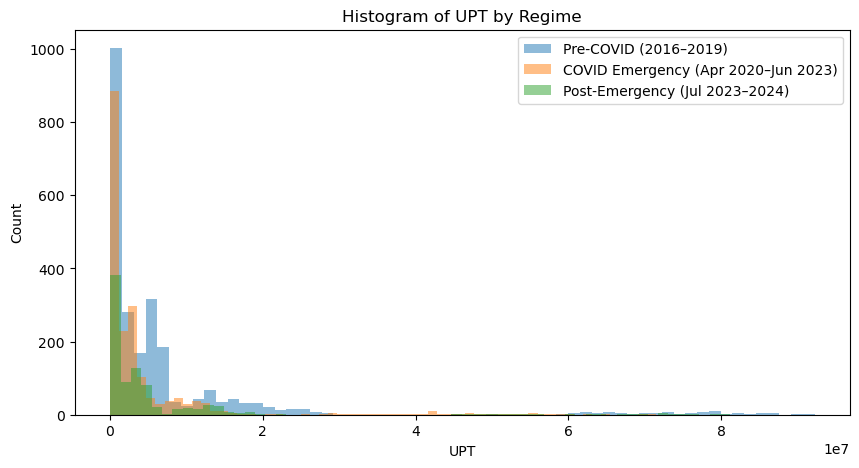

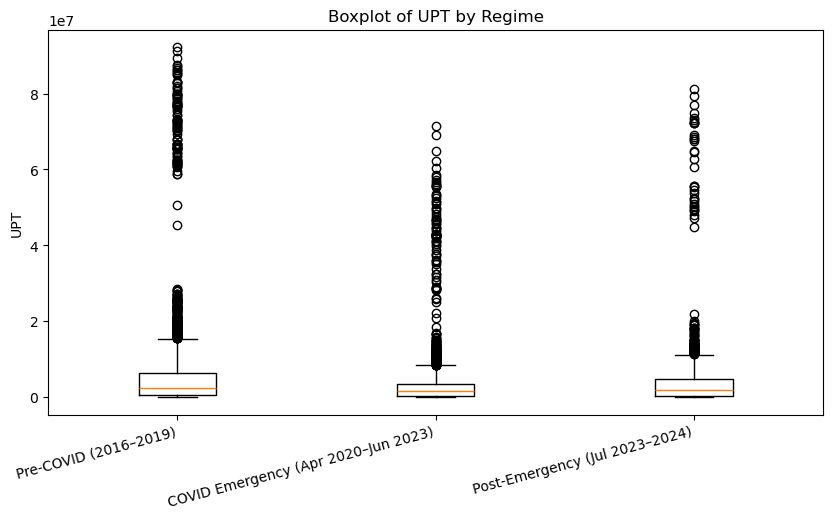

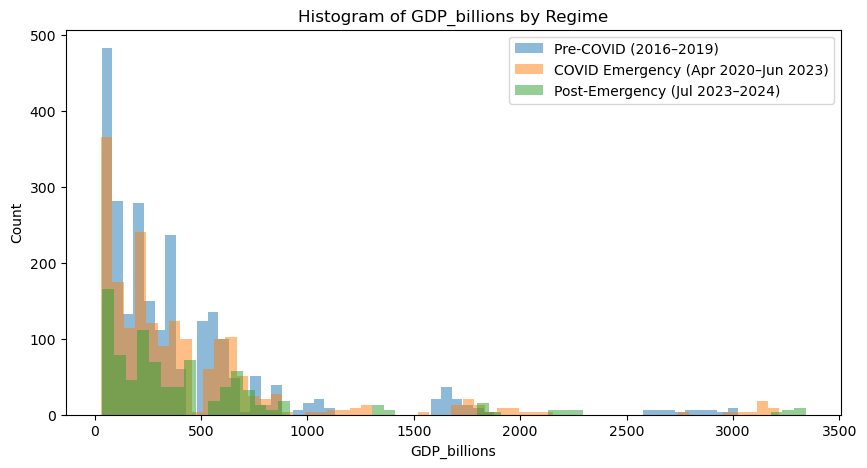

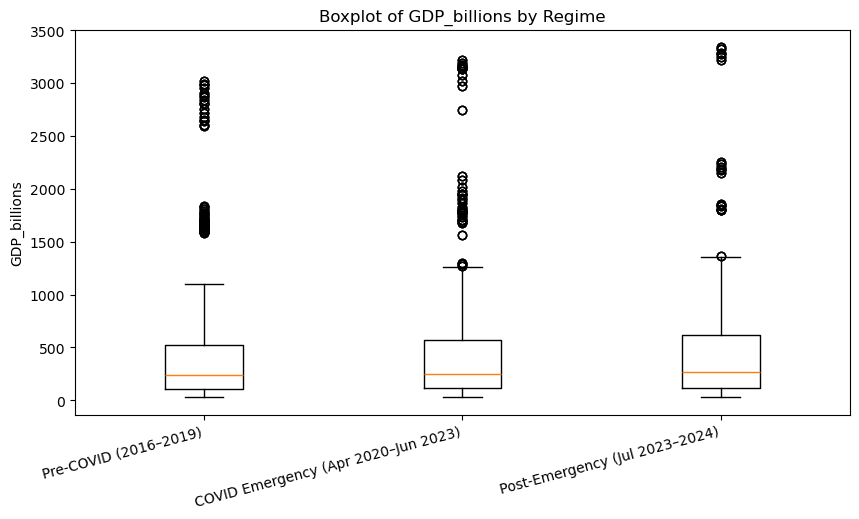

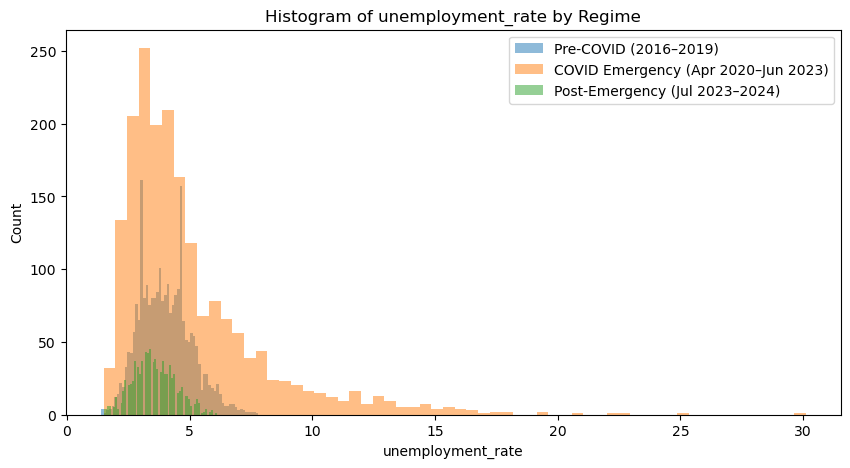

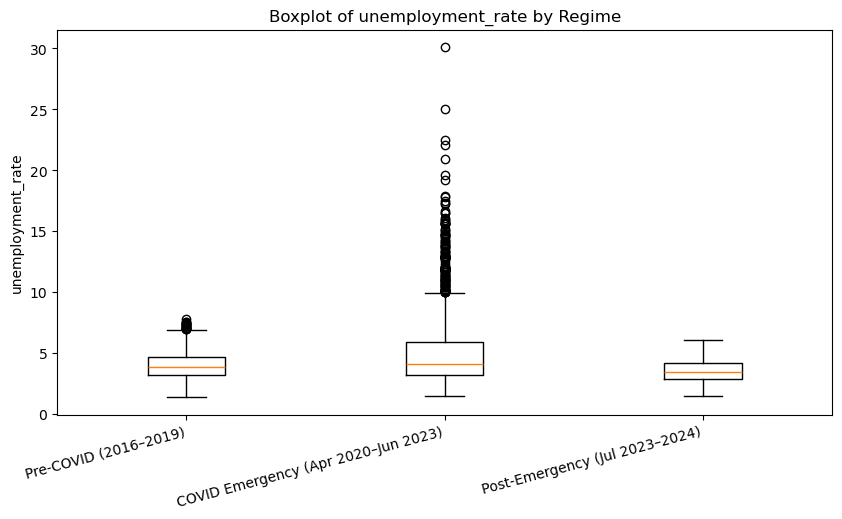

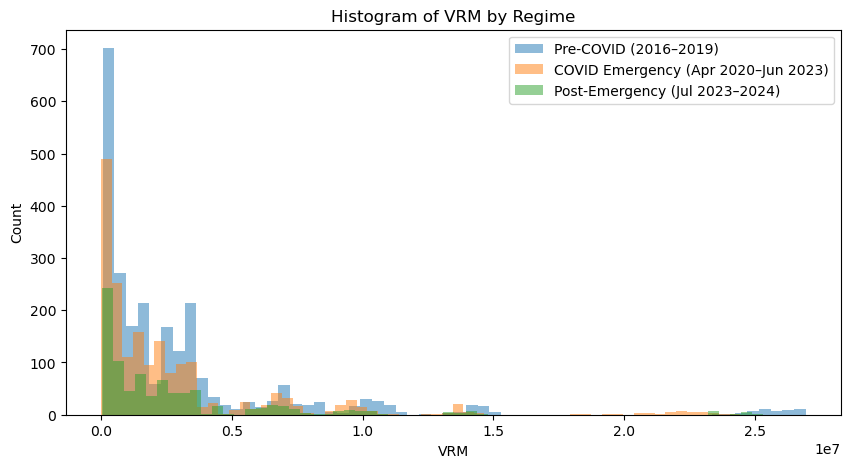

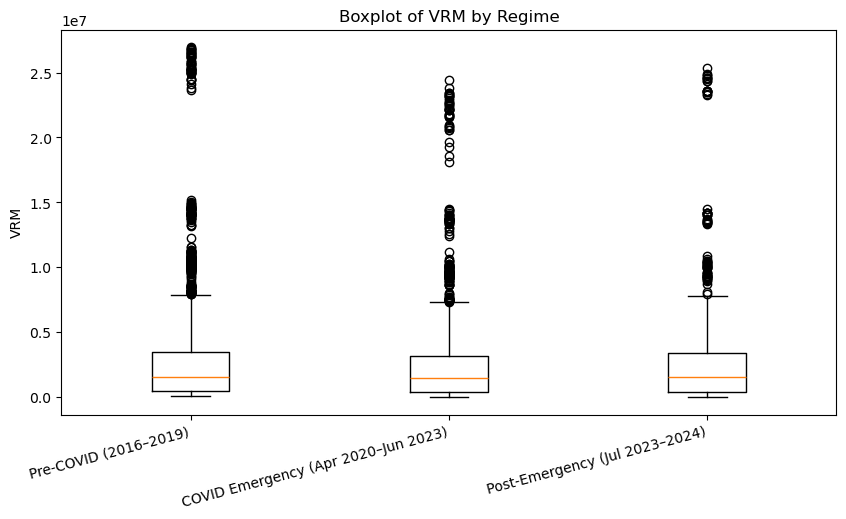

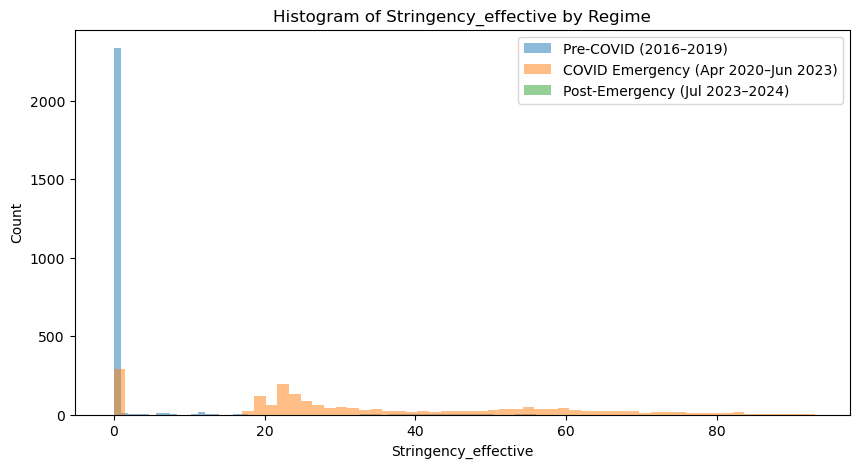

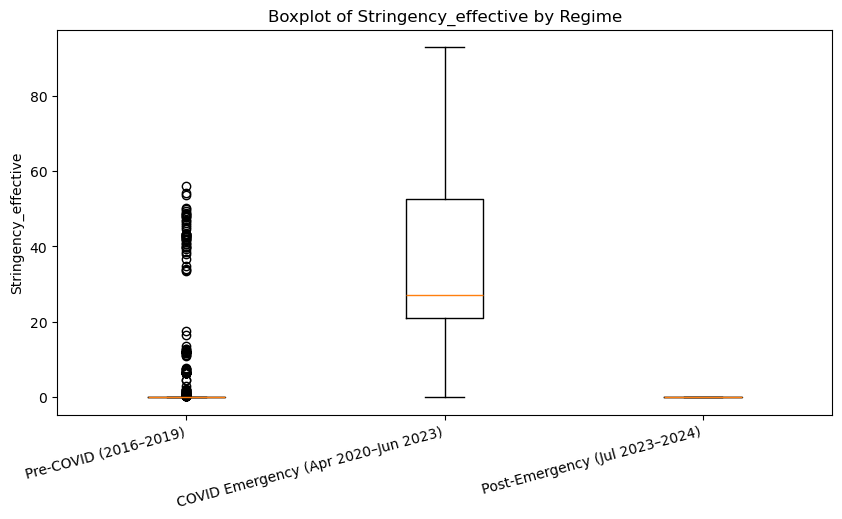

In [13]:
def plot_hist_by_regime(var, bins=50):
    data = df[[var, "regime"]].dropna()
    regimes = data["regime"].unique()

    plt.figure(figsize=(10, 5))
    for r in regimes:
        plt.hist(data.loc[data["regime"] == r, var], bins=bins, alpha=0.5, label=r)
    plt.title(f"Histogram of {var} by Regime")
    plt.xlabel(var)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

def plot_box_by_regime(var):
    data = df[[var, "regime"]].dropna()
    order = ["Pre-COVID (2016–2019)", "COVID Emergency (Apr 2020–Jun 2023)", "Post-Emergency (Jul 2023–2024)"]

    plt.figure(figsize=(10, 5))
    df_plot = [data.loc[data["regime"] == r, var].values for r in order if r in data["regime"].unique()]
    plt.boxplot(df_plot, tick_labels=[r for r in order if r in data["regime"].unique()], showfliers=True)
    plt.title(f"Boxplot of {var} by Regime")
    plt.ylabel(var)
    plt.xticks(rotation=15, ha="right")
    plt.show()

for v in cont_vars:
    plot_hist_by_regime(v, bins=60)
    plot_box_by_regime(v)

# Bivariate relationships (scatter) by regime

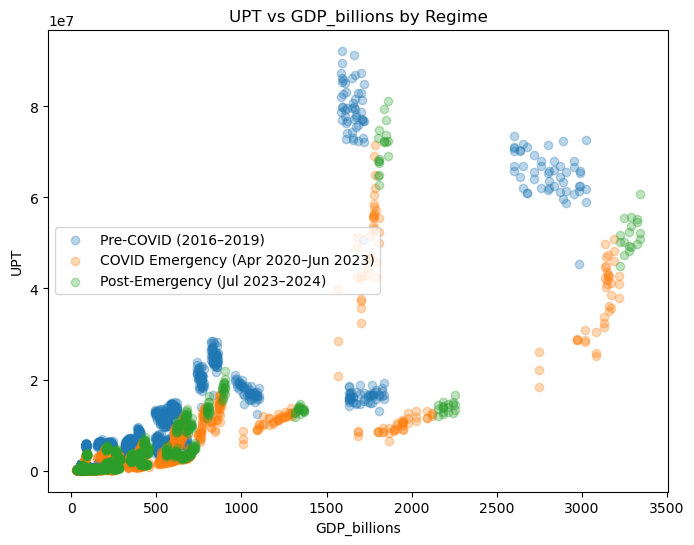

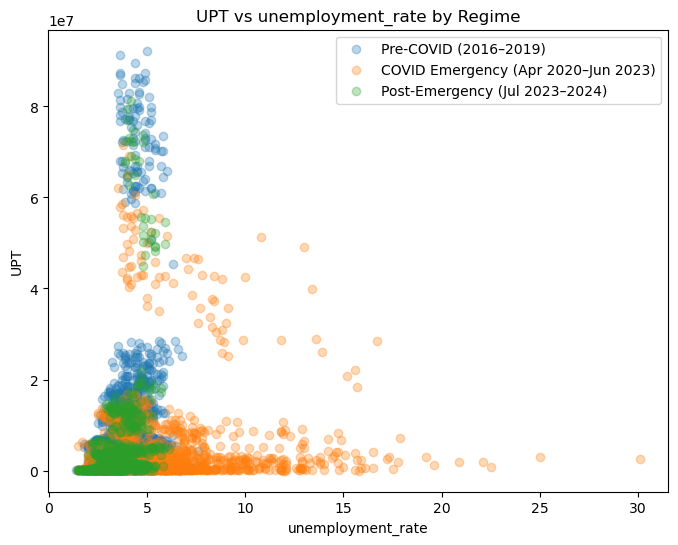

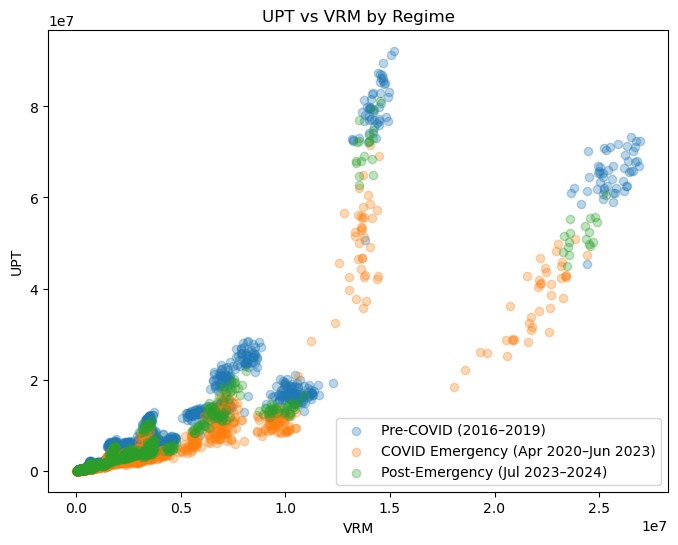

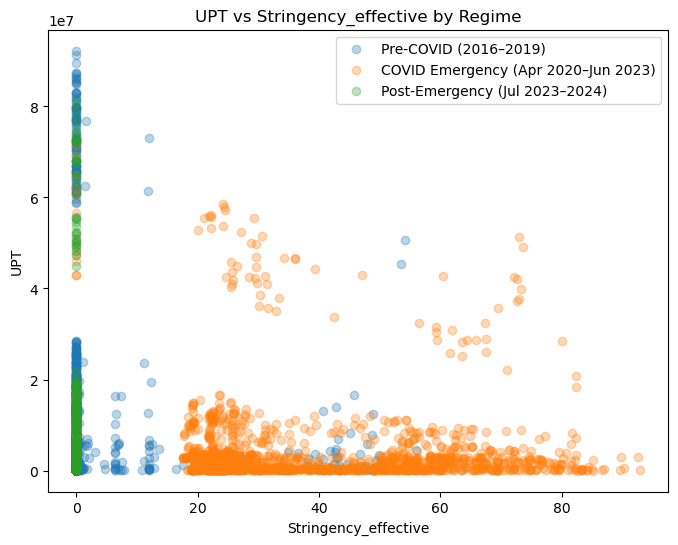

In [14]:
def scatter_by_regime(x, y="UPT", sample=20000):
    sub = df[[x, y, "regime"]].dropna()

    # Sample for speed
    #if len(sub) > sample:
    #    sub = sub.sample(sample, random_state=42)

    plt.figure(figsize=(8, 6))
    for r in sub["regime"].unique():
        plt.scatter(sub.loc[sub["regime"] == r, x],
                    sub.loc[sub["regime"] == r, y],
                    alpha=0.3, label=r)
    plt.title(f"{y} vs {x} by Regime")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.legend()
    plt.show()

for x in ["GDP_billions", "unemployment_rate", "VRM", "Stringency_effective"]:
    if x in df.columns:
        scatter_by_regime(x)

# Robust Association Diagnostics (Correlation + Tests)
#### Purpose:
   - Pearson vs Spearman comparison
   - Residual-based tests (linearity proxy, heteroskedasticity)
   - Influence/outlier flags (Cook's distance, leverage, studentized residuals)
   - Correlations computed:
       1) Global (all rows)
       2) Within-state (demeaned by state)
       3) By regime (Pre / Emergency / Post)
   - Final summary table: "which test failed and which correlation to prefer"

## CONFIG and HELPERS

In [15]:
# CONFIG — choose variables
STATE_COL = "state"
DATE_COL = "date"
REGIME_COL = "regime"
Y_COL = "UPT"

# predictors to evaluate association with UPT
X_COLS = [
    "GDP_billions",
    "unemployment_rate",
    "VRM",
    "Stringency_effective",
    "is_red"
]

# restrict to continuous-only correlation matrix
CONT_COLS = ["UPT", "GDP_billions", "unemployment_rate", "VRM", "Stringency_effective"]

# Basic sanity checks
required = {STATE_COL, DATE_COL, REGIME_COL, Y_COL}.union(X_COLS)
missing_req = [c for c in required if c not in df.columns]
if missing_req:
    raise ValueError(f"Missing required columns in df: {missing_req}")

# -------------------------
# Helper — within-state demeaning
def add_within_state_columns(data: pd.DataFrame, cols, state_col=STATE_COL) -> pd.DataFrame:
    out = data.copy()
    for c in cols:
        out[f"{c}_within"] = out[c] - out.groupby(state_col)[c].transform("mean")
    return out

# -------------------------
# Helper — pair diagnostics
def _safe_pearsonr(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    if np.nanstd(a) == 0 or np.nanstd(b) == 0:
        return (np.nan, np.nan)
    return stats.pearsonr(a, b)

def _safe_spearmanr(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    if np.nanstd(a) == 0 or np.nanstd(b) == 0:
        return (np.nan, np.nan)
    return stats.spearmanr(a, b)

def pair_diagnostics(data: pd.DataFrame, x: str, y: str, max_shapiro_n=5000) -> dict:
    """
    Diagnostics for relationship y ~ x using OLS residual checks.
    Returns:
      - Pearson and Spearman correlations
      - BP heteroskedasticity p-value
      - Shapiro p-value on residuals (sampled if large)
      - Influence/outlier flag counts
      - A simple linearity proxy: corr(x, residuals) (should be ~0 for linear)
    """

    
    tmp = data[[x, y]].dropna()
    n = len(tmp)
    X = sm.add_constant(tmp[x].astype(float))
    Y = tmp[y].astype(float)

    model = sm.OLS(Y, X).fit()
    resid = model.resid

    
    # Correlations
    pearson_r, pearson_p = _safe_pearsonr(tmp[x], tmp[y])
    spearman_r, spearman_p = _safe_spearmanr(tmp[x], tmp[y])

    # Heteroskedasticity: Breusch–Pagan
    bp = het_breuschpagan(resid, model.model.exog)
    bp_pvalue = bp[1]

    # Linearity proxy (rough): corr(x, residuals)
    lin_check, _ = _safe_pearsonr(tmp[x], resid)

    # Influence / outliers
    infl = OLSInfluence(model)
    cooks = infl.cooks_distance[0]
    leverage = infl.hat_matrix_diag
    stud_resid = infl.resid_studentized_external

    # Common heuristic thresholds
    cooks_flags = int((cooks > (4 / n)).sum())
    leverage_flags = int((leverage > (2 * X.shape[1] / n)).sum())
    outlier_flags = int((np.abs(stud_resid) > 3).sum())

    # Normality of residuals: Shapiro on a sample if large
    if n >= 3:
        sample_resid = resid.sample(min(n, max_shapiro_n), random_state=1)
        shapiro_p = stats.shapiro(sample_resid)[1]
    else:
        shapiro_p = np.nan

    return {
        "x": x, "y": y, "n": n,
        "pearson_r": pearson_r, "pearson_p": pearson_p,
        "spearman_r": spearman_r, "spearman_p": spearman_p,
        "bp_pvalue": bp_pvalue,
        "shapiro_p_resid": shapiro_p,
        "lin_check_corr_x_resid": lin_check,
        "cooks_flags": cooks_flags,
        "leverage_flags": leverage_flags,
        "outlier_flags": outlier_flags
    }

# -------------------------
# Helper — decide which correlation to prefer

def choose_corr_method(row,
                       bp_alpha=0.05,
                       shapiro_alpha=0.05,
                       lin_tol=0.10,
                       influence_flag_threshold=1) -> tuple[str, str]:
    """
    Simple rule-based recommendation:
      - Prefer Spearman if there are influence/outlier signals, non-linearity signals, or strong heteroskedasticity.
      - Pearson is acceptable if relationship looks roughly linear, with low influence flags.
    Returns:
      (recommended_method, reasons_string)
    """
    reasons = []

    # Influence / outliers
    if (row["outlier_flags"] is not np.nan and row["outlier_flags"] >= influence_flag_threshold) or \
       (row["cooks_flags"] is not np.nan and row["cooks_flags"] >= influence_flag_threshold):
        reasons.append("influential_outliers")

    # Linearity proxy (corr(x, residuals) should be close to 0)
    if row["lin_check_corr_x_resid"] is not np.nan and abs(row["lin_check_corr_x_resid"]) > lin_tol:
        reasons.append("nonlinearity_signal")

    # Heteroskedasticity (more relevant to modeling, but also a warning)
    if row["bp_pvalue"] is not np.nan and row["bp_pvalue"] < bp_alpha:
        reasons.append("heteroskedasticity")

    # Residual normality (weak criterion for correlation itself; include as a note)
    if row["shapiro_p_resid"] is not np.nan and row["shapiro_p_resid"] < shapiro_alpha:
        reasons.append("non_normal_residuals")

    # Decision
    if any(r in reasons for r in ["influential_outliers", "nonlinearity_signal"]):
        return "Spearman (rank)", ", ".join(reasons) if reasons else "ok"
    else:
        # If only heteroskedasticity/non-normal, Pearson can still be fine as a descriptive measure
        return "Pearson (linear)", ", ".join(reasons) if reasons else "ok"

## Global Pearson vs Spearman + diagnostics (UPT vs each X)

In [16]:
global_results = [pair_diagnostics(df, x, Y_COL) for x in X_COLS]
global_tbl = pd.DataFrame(global_results)

global_tbl[["recommended_method", "reasons"]] = global_tbl.apply(
    lambda r: pd.Series(choose_corr_method(r)),
    axis=1
)

# Sort by absolute association strength (Spearman by default for ranking)
global_tbl = global_tbl.sort_values(by="spearman_r", key=lambda s: s.abs(), ascending=False)

print("=== Global UPT associations (Pearson vs Spearman + diagnostics) ===")
display(global_tbl)

=== Global UPT associations (Pearson vs Spearman + diagnostics) ===


,x,y,n,pearson_r,pearson_p,spearman_r,spearman_p,bp_pvalue,shapiro_p_resid,lin_check_corr_x_resid,cooks_flags,leverage_flags,outlier_flags,recommended_method,reasons
2,VRM,UPT,5184,0.870990,0.000000e+00,0.971783,0.000000e+00,1.787914e-197,1.037659e-78,8.049117e-16,317,275,105,Spearman (rank),"influential_outliers, heteroskedasticity, non_..."
0,GDP_billions,UPT,5184,0.800512,0.000000e+00,0.855208,0.000000e+00,8.223373e-243,3.817991e-74,2.775558e-17,316,327,155,Spearman (rank),"influential_outliers, heteroskedasticity, non_..."
4,is_red,UPT,5184,-0.274481,2.914586e-90,-0.339118,1.101887e-139,3.584674e-54,2.788697e-77,-1.325329e-15,199,0,165,Spearman (rank),"influential_outliers, heteroskedasticity, non_..."
1,unemployment_rate,UPT,5184,0.078039,1.843970e-08,0.229597,5.543334e-63,1.107685e-03,1.812991e-80,1.318390e-16,266,233,172,Spearman (rank),"influential_outliers, heteroskedasticity, non_..."
3,Stringency_effective,UPT,5184,-0.096053,4.203466e-12,-0.138461,1.309098e-23,1.300786e-07,1.382494e-80,-4.518955e-16,216,542,178,Spearman (rank),"influential_outliers, heteroskedasticity, non_..."


## Within-state correlations (demeaned by state)
Why: Separate within-state dynamics from between-state level differences

In [17]:
within_df = add_within_state_columns(df, [Y_COL] + X_COLS, state_col=STATE_COL)

within_results = [pair_diagnostics(within_df, f"{x}_within", f"{Y_COL}_within") for x in X_COLS]
within_tbl = pd.DataFrame(within_results)

# rename x labels back for readability
within_tbl["x_original"] = within_tbl["x"].str.replace("_within", "", regex=False)
within_tbl = within_tbl.drop(columns=["x"]).rename(columns={"x_original": "x"})

within_tbl[["recommended_method", "reasons"]] = within_tbl.apply(
    lambda r: pd.Series(choose_corr_method(r)),
    axis=1
)

within_tbl = within_tbl.sort_values(by="spearman_r", key=lambda s: s.abs(), ascending=False)

print("=== Within-state (demeaned) UPT associations (Pearson vs Spearman + diagnostics) ===")
display(within_tbl)


=== Within-state (demeaned) UPT associations (Pearson vs Spearman + diagnostics) ===


,y,n,pearson_r,pearson_p,spearman_r,spearman_p,bp_pvalue,shapiro_p_resid,lin_check_corr_x_resid,cooks_flags,leverage_flags,outlier_flags,x,recommended_method,reasons
2,UPT_within,5184,0.708587,0.000000e+00,0.619373,0.000000e+00,3.251201e-05,5.786135e-75,8.673617e-16,261,230,108,VRM,Spearman (rank),"influential_outliers, heteroskedasticity, non_..."
3,UPT_within,5184,-0.404463,2.659187e-203,-0.588087,0.000000e+00,1.288142e-24,6.385993e-74,8.326673e-16,267,553,125,Stringency_effective,Spearman (rank),"influential_outliers, heteroskedasticity, non_..."
0,UPT_within,5184,-0.309628,1.405129e-115,-0.543268,0.000000e+00,2.669758e-10,5.463555e-78,-9.020562e-17,266,291,114,GDP_billions,Spearman (rank),"influential_outliers, heteroskedasticity, non_..."
4,UPT_within,5184,0.152130,3.240044e-28,0.303327,8.974619e-111,9.884060e-01,1.397726e-77,8.673617e-17,210,552,131,is_red,Spearman (rank),"influential_outliers, non_normal_residuals"
1,UPT_within,5184,-0.304826,6.618500e-112,-0.145097,8.629492e-26,1.131093e-35,1.326252e-73,1.422473e-16,254,226,129,unemployment_rate,Spearman (rank),"influential_outliers, heteroskedasticity, non_..."


## By-regime correlations (Pre / Emergency / Post)

In [18]:
regime_tables = []

for reg in sorted(df[REGIME_COL].dropna().unique()):
    sub = df[df[REGIME_COL] == reg].copy()
    res = [pair_diagnostics(sub, x, Y_COL) for x in X_COLS]
    t = pd.DataFrame(res)
    t[REGIME_COL] = reg
    t[["recommended_method", "reasons"]] = t.apply(lambda r: pd.Series(choose_corr_method(r)), axis=1)
    regime_tables.append(t)

regime_tbl = pd.concat(regime_tables, ignore_index=True)

# Create helper column for sorting by absolute Spearman
regime_tbl["abs_spearman_r"] = regime_tbl["spearman_r"].abs()

# Sort: first by regime (string), then by abs spearman descending
regime_tbl = regime_tbl.sort_values([REGIME_COL, "abs_spearman_r"], ascending=[True, False]).drop(columns=["abs_spearman_r"])

print("=== By-regime UPT associations (Pearson vs Spearman + diagnostics) ===")
display(regime_tbl)

=== By-regime UPT associations (Pearson vs Spearman + diagnostics) ===


,x,y,n,pearson_r,pearson_p,spearman_r,spearman_p,bp_pvalue,shapiro_p_resid,lin_check_corr_x_resid,cooks_flags,leverage_flags,outlier_flags,regime,recommended_method,reasons
2,VRM,UPT,1872,0.873114,0.000000e+00,0.972079,0.000000e+00,3.254987e-70,3.501024e-57,1.026956e-15,109,103,37,COVID Emergency (Apr 2020–Jun 2023),Spearman (rank),"influential_outliers, heteroskedasticity, non_..."
0,GDP_billions,UPT,1872,0.819063,0.000000e+00,0.867798,0.000000e+00,1.450627e-70,2.237616e-55,-3.053113e-16,105,117,38,COVID Emergency (Apr 2020–Jun 2023),Spearman (rank),"influential_outliers, heteroskedasticity, non_..."
4,is_red,UPT,1872,-0.283054,7.951173e-36,-0.449461,9.487819e-94,2.104669e-16,8.557762e-57,1.498801e-15,75,0,61,COVID Emergency (Apr 2020–Jun 2023),Spearman (rank),"influential_outliers, heteroskedasticity, non_..."
1,unemployment_rate,UPT,1872,0.096463,2.907717e-05,0.207077,1.406023e-19,5.152978e-02,1.119598e-58,7.632783e-17,92,121,62,COVID Emergency (Apr 2020–Jun 2023),Spearman (rank),"influential_outliers, non_normal_residuals"
3,Stringency_effective,UPT,1872,-0.055480,1.636506e-02,-0.081971,3.848952e-04,2.472273e-02,3.722236e-59,-3.426079e-17,78,98,65,COVID Emergency (Apr 2020–Jun 2023),Spearman (rank),"influential_outliers, heteroskedasticity, non_..."
7,VRM,UPT,864,0.870356,1.947917e-267,0.979589,0.000000e+00,8.288300e-38,5.244120e-44,-1.387779e-16,55,43,18,Post-Emergency (Jul 2023–2024),Spearman (rank),"influential_outliers, heteroskedasticity, non_..."
5,GDP_billions,UPT,864,0.809579,1.253718e-201,0.867561,1.007554e-263,9.483916e-38,2.420868e-42,-8.326673e-16,43,54,25,Post-Emergency (Jul 2023–2024),Spearman (rank),"influential_outliers, heteroskedasticity, non_..."
6,unemployment_rate,UPT,864,0.351067,1.840684e-26,0.464924,1.507115e-47,9.805930e-12,1.226268e-40,-6.245005e-17,43,82,30,Post-Emergency (Jul 2023–2024),Spearman (rank),"influential_outliers, heteroskedasticity, non_..."
9,is_red,UPT,864,-0.296794,4.972656e-19,-0.330938,1.578949e-23,4.234083e-13,1.357566e-41,-6.383782e-16,36,0,35,Post-Emergency (Jul 2023–2024),Spearman (rank),"influential_outliers, heteroskedasticity, non_..."
8,Stringency_effective,UPT,864,NaN,NaN,NaN,NaN,9.999996e-01,5.645102e-45,NaN,36,0,36,Post-Emergency (Jul 2023–2024),Spearman (rank),"influential_outliers, non_normal_residuals"


## Correlation matrices (global vs within-state; Pearson + Spearman)

In [19]:
# 1 Global correlation matrices (continuous only)
global_cont = df[CONT_COLS].dropna()

pearson_mat = global_cont.corr(method="pearson")
spearman_mat = global_cont.corr(method="spearman")

print("=== Global Pearson correlation matrix (continuous vars) ===")
display(pearson_mat)

print("=== Global Spearman correlation matrix (continuous vars) ===")
display(spearman_mat)

# 2 Within-state correlation matrices (continuous only)
within_cont_cols = [f"{c}_within" for c in CONT_COLS]
within_cont = within_df[within_cont_cols].dropna()

within_pearson = within_cont.corr(method="pearson")
within_spearman = within_cont.corr(method="spearman")

# Rename for readability
within_pearson.index = [c.replace("_within", "") for c in within_pearson.index]
within_pearson.columns = [c.replace("_within", "") for c in within_pearson.columns]
within_spearman.index = [c.replace("_within", "") for c in within_spearman.index]
within_spearman.columns = [c.replace("_within", "") for c in within_spearman.columns]

print("=== Within-state Pearson correlation matrix (continuous vars) ===")
display(within_pearson)

print("=== Within-state Spearman correlation matrix (continuous vars) ===")
display(within_spearman)

=== Global Pearson correlation matrix (continuous vars) ===


,UPT,GDP_billions,unemployment_rate,VRM,Stringency_effective
UPT,1.000000,0.800512,0.078039,0.870990,-0.096053
GDP_billions,0.800512,1.000000,0.135704,0.961019,0.007927
unemployment_rate,0.078039,0.135704,1.000000,0.145335,0.609355
VRM,0.870990,0.961019,0.145335,1.000000,-0.016867
Stringency_effective,-0.096053,0.007927,0.609355,-0.016867,1.000000


=== Global Spearman correlation matrix (continuous vars) ===


,UPT,GDP_billions,unemployment_rate,VRM,Stringency_effective
UPT,1.000000,0.855208,0.229597,0.971783,-0.138461
GDP_billions,0.855208,1.000000,0.217847,0.914209,0.004529
unemployment_rate,0.229597,0.217847,1.000000,0.268843,0.308060
VRM,0.971783,0.914209,0.268843,1.000000,-0.025068
Stringency_effective,-0.138461,0.004529,0.308060,-0.025068,1.000000


=== Within-state Pearson correlation matrix (continuous vars) ===


,UPT,GDP_billions,unemployment_rate,VRM,Stringency_effective
UPT,1.000000,-0.309628,-0.304826,0.708587,-0.404463
GDP_billions,-0.309628,1.000000,-0.178222,-0.254471,-0.021243
unemployment_rate,-0.304826,-0.178222,1.000000,-0.309887,0.659217
VRM,0.708587,-0.254471,-0.309887,1.000000,-0.334487
Stringency_effective,-0.404463,-0.021243,0.659217,-0.334487,1.000000


=== Within-state Spearman correlation matrix (continuous vars) ===


,UPT,GDP_billions,unemployment_rate,VRM,Stringency_effective
UPT,1.000000,-0.543268,-0.145097,0.619373,-0.588087
GDP_billions,-0.543268,1.000000,-0.354090,-0.307469,0.066024
unemployment_rate,-0.145097,-0.354090,1.000000,-0.143696,0.373238
VRM,0.619373,-0.307469,-0.143696,1.000000,-0.342117
Stringency_effective,-0.588087,0.066024,0.373238,-0.342117,1.000000


## Final summary table (what failed, what we use)
Combine: Global + Within-state + By-regime into one compact audit view

In [20]:
def compact_view(tbl, label):
    out = tbl.copy()
    out["scope"] = label
    cols = ["scope"]
    if REGIME_COL in out.columns:
        cols += [REGIME_COL]
    cols += ["x", "n", "pearson_r", "spearman_r", "bp_pvalue",
             "lin_check_corr_x_resid", "outlier_flags", "cooks_flags",
             "recommended_method", "reasons"]
    return out[cols]

final_audit = pd.concat([
    compact_view(global_tbl, "Global"),
    compact_view(within_tbl, "Within-state"),
    compact_view(regime_tbl, "By-regime")
], ignore_index=True)

# Make it easier to scan
final_audit = final_audit.sort_values(
    by=["scope", REGIME_COL, "spearman_r"],
    key=lambda s: s.abs() if s.name == "spearman_r" else s,
    ascending=[True, True, False]
)

print("=== Final audit table: diagnostics + recommended correlation method ===")
display(final_audit)

# Save audit outputs for reporting
final_audit.to_csv("Correlation_Diagnostics_Audit.csv", index=False)
print("Saved: Correlation_Diagnostics_Audit.csv")

=== Final audit table: diagnostics + recommended correlation method ===


,scope,x,n,pearson_r,spearman_r,bp_pvalue,lin_check_corr_x_resid,outlier_flags,cooks_flags,recommended_method,reasons,regime
10,By-regime,VRM,1872,0.873114,0.972079,3.254987e-70,1.026956e-15,37,109,Spearman (rank),"influential_outliers, heteroskedasticity, non_...",COVID Emergency (Apr 2020–Jun 2023)
11,By-regime,GDP_billions,1872,0.819063,0.867798,1.450627e-70,-3.053113e-16,38,105,Spearman (rank),"influential_outliers, heteroskedasticity, non_...",COVID Emergency (Apr 2020–Jun 2023)
12,By-regime,is_red,1872,-0.283054,-0.449461,2.104669e-16,1.498801e-15,61,75,Spearman (rank),"influential_outliers, heteroskedasticity, non_...",COVID Emergency (Apr 2020–Jun 2023)
13,By-regime,unemployment_rate,1872,0.096463,0.207077,5.152978e-02,7.632783e-17,62,92,Spearman (rank),"influential_outliers, non_normal_residuals",COVID Emergency (Apr 2020–Jun 2023)
14,By-regime,Stringency_effective,1872,-0.055480,-0.081971,2.472273e-02,-3.426079e-17,65,78,Spearman (rank),"influential_outliers, heteroskedasticity, non_...",COVID Emergency (Apr 2020–Jun 2023)
15,By-regime,VRM,864,0.870356,0.979589,8.288300e-38,-1.387779e-16,18,55,Spearman (rank),"influential_outliers, heteroskedasticity, non_...",Post-Emergency (Jul 2023–2024)
16,By-regime,GDP_billions,864,0.809579,0.867561,9.483916e-38,-8.326673e-16,25,43,Spearman (rank),"influential_outliers, heteroskedasticity, non_...",Post-Emergency (Jul 2023–2024)
17,By-regime,unemployment_rate,864,0.351067,0.464924,9.805930e-12,-6.245005e-17,30,43,Spearman (rank),"influential_outliers, heteroskedasticity, non_...",Post-Emergency (Jul 2023–2024)
18,By-regime,is_red,864,-0.296794,-0.330938,4.234083e-13,-6.383782e-16,35,36,Spearman (rank),"influential_outliers, heteroskedasticity, non_...",Post-Emergency (Jul 2023–2024)
19,By-regime,Stringency_effective,864,NaN,NaN,9.999996e-01,NaN,36,36,Spearman (rank),"influential_outliers, non_normal_residuals",Post-Emergency (Jul 2023–2024)


Saved: Correlation_Diagnostics_Audit.csv


# Multicollinearity Screening (VIF)

In [21]:
STATE_COL = "state"
Y_COL = "UPT"

# Choose predictors for VIF (avoid including both red/blue; use is_red only)
VIF_COLS = ["GDP_billions", "unemployment_rate", "VRM", "Stringency_effective", "is_red"]

def compute_vif(data: pd.DataFrame, cols):
    tmp = data[cols].dropna().copy()

    # If there are too many rows, sample for speed (optional)
    if len(tmp) > 200000:
        tmp = tmp.sample(200000, random_state=42)

    # Add constant for VIF computation
    X = sm.add_constant(tmp.astype(float))

    vif_data = []
    for i, c in enumerate(X.columns):
        if c == "const":
            continue
        vif = variance_inflation_factor(X.values, i)
        vif_data.append({"variable": c, "VIF": vif})

    return pd.DataFrame(vif_data).sort_values("VIF", ascending=False)

# 1) Global VIF
vif_global = compute_vif(df, VIF_COLS)
print("=== VIF (Global) ===")
display(vif_global)

# 2) Within-state VIF (demeaned)
within = df.copy()
for c in VIF_COLS + [Y_COL]:
    within[c + "_within"] = within[c] - within.groupby(STATE_COL)[c].transform("mean")

vif_within = compute_vif(within, [c + "_within" for c in VIF_COLS])
vif_within["variable"] = vif_within["variable"].str.replace("_within", "", regex=False)

print("=== VIF (Within-state / demeaned) ===")
display(vif_within)

# Save for reporting
vif_global.to_csv("VIF_Global.csv", index=False)
vif_within.to_csv("VIF_WithinState.csv", index=False)
print("Saved: VIF_Global.csv, VIF_WithinState.csv")

=== VIF (Global) ===


,variable,VIF
2,VRM,16.282351
0,GDP_billions,15.375749
3,Stringency_effective,1.674492
1,unemployment_rate,1.668680
4,is_red,1.252552


=== VIF (Within-state / demeaned) ===


,variable,VIF
1,unemployment_rate,1.953787
3,Stringency_effective,1.926695
2,VRM,1.273037
0,GDP_billions,1.166786
4,is_red,1.061633


Saved: VIF_Global.csv, VIF_WithinState.csv


# Transformation Audit (Skewness / Kurtosis + Log suggestion)
We screened skewness and non-negativity to identify candidates for log1p transforms; final transform choices will be confirmed in the modeling notebook based on residual diagnostics and interpretability

In [23]:
TRANSFORM_COLS = ["UPT", "GDP_billions", "unemployment_rate", "VRM", "Stringency_effective"]

def transformation_audit(data: pd.DataFrame, cols, skew_threshold=1.0):
    rows = []
    for c in cols:
        s = data[c].dropna()
        if len(s) < 30:
            rows.append({"variable": c, "n": len(s), "skew": np.nan, "kurtosis": np.nan,
                         "min": s.min() if len(s) else np.nan, "zeros_pct": np.nan,
                         "suggest_log1p": False})
            continue

        skew = stats.skew(s, bias=False)
        kurt = stats.kurtosis(s, bias=False)  # excess kurtosis
        zeros_pct = (s == 0).mean() * 100 if np.issubdtype(s.dtype, np.number) else np.nan

        suggest = (abs(skew) >= skew_threshold) and (s.min() >= 0)  # log1p needs non-negative
        rows.append({
            "variable": c,
            "n": len(s),
            "skew": float(skew),
            "kurtosis_excess": float(kurt),
            "min": float(s.min()),
            "zeros_pct": float(zeros_pct),
            "suggest_log1p": bool(suggest)
        })
    return pd.DataFrame(rows).sort_values("suggest_log1p", ascending=False)

audit_tbl = transformation_audit(df, TRANSFORM_COLS, skew_threshold=1.0)
print("=== Transformation audit (log1p suggestions) ===")
display(audit_tbl)

audit_tbl.to_csv("Transformation_Audit.csv", index=False)
print("Saved: Transformation_Audit.csv")

=== Transformation audit (log1p suggestions) ===


,variable,n,skew,kurtosis_excess,min,zeros_pct,suggest_log1p
0,UPT,5184,4.105111,18.198137,0.00,0.038580,True
1,GDP_billions,5184,2.988085,10.280942,30.06,0.000000,True
2,unemployment_rate,5184,3.329656,19.226770,1.40,0.000000,True
3,VRM,5184,3.036337,11.077166,0.00,0.038580,True
4,Stringency_effective,5184,1.584983,1.431699,0.00,66.666667,True


Saved: Transformation_Audit.csv


# Save prepared dataset for modeling notebook

In [22]:
OUT_PATH = Path("MasterPanel_prelim_cleaned_2016_2024.csv")
df.to_csv(OUT_PATH, index=False)

print(f"Saved cleaned dataset to: {OUT_PATH.resolve()}")
print("Final shape:", df.shape)

Saved cleaned dataset to: C:\Users\jjvar\University\Capstone\MasterPanel_prelim_cleaned_2016_2024.csv
Final shape: (5184, 24)
